ライブラリのインポート

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns
from sklearn.model_selection import train_test_split #* train_test_splitは、データを学習用データとテスト用データに分けるための関数
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #* mean_squared_errorはMSE、mean_absolute_errorはMAE、r2_scoreはR2を計算するための関数
from sklearn.linear_model import Lasso #* Lassoは、不要な特徴量の係数を0に近づけながら回帰分析を行うモデル

CSVファイルの読み込み

In [13]:
csv_path = "/Users/ka-sana/Desktop/MI研/Pythonセミナー/第4回/feature_engineering_dataset.csv"
df = pd.read_csv(csv_path) #* pd.read_csvは、指定したCSVファイルを読み込んでDataFrameという表形式データに変換する関数
print(df.head()) #* head()は、データの先頭5行を表示して、列名や値を確認するための関数

         x1        x2        x3        x4          y
0 -1.254599 -3.148671 -2.382943  1.727030   4.474510
1  4.507143  0.419009 -2.530212  2.966814  16.006309
2  2.319939  3.729458  4.062546 -2.495321  -1.629434
3  0.986585  2.322249 -2.504538  1.248741   1.787929
4 -3.439814  3.065611 -2.280503  0.717460   5.071840


予測精度を評価してグラフを描く関数

In [14]:
#* pred_plotは、予測精度を計算し、予測値と実測値の散布図を描くために自分で定義する関数
def pred_plot(train_targets, train_predictions, test_targets, test_predictions, model_name):
    train_mse = mean_squared_error(train_targets, train_predictions) #* mean_squared_errorは、学習データにおける実測値と予測値のずれの二乗平均を計算
    train_mae = mean_absolute_error(train_targets, train_predictions) #* mean_absolute_errorは、学習データにおける実測値と予測値のずれの絶対値平均を計算
    train_r2 = r2_score(train_targets, train_predictions) #* r2_scoreは、学習データにおける決定係数R2を計算
    train_rmse = np.sqrt(train_mse) #* np.sqrtは平方根を計算する関数で、MSEの平方根を取ることでRMSEを求める
    
    test_mse = mean_squared_error(test_targets, test_predictions) #* テストデータにおけるMSEを計算
    test_mae = mean_absolute_error(test_targets, test_predictions) #* テストデータにおけるMAEを計算
    test_r2 = r2_score(test_targets, test_predictions) #* テストデータにおける決定係数R2を計算
    test_rmse = np.sqrt(test_mse) #* テストデータにおけるRMSEを計算

    print(f"\n{model_name} Training Set Performance:")
    print(f"Samples: {len(train_predictions)} | RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R2: {train_r2:.4f}") #* 小数第4位まで表示(学習データ)
    print(f"\n{model_name} Test Set Performance:") #* テストデータの評価結果を表示するための見出しを表示
    print(f"Samples: {len(test_predictions)} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R2: {test_r2:.4f}") #* 小数第4位まで表示(テストデータ)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6)) #* plt.subplotsは、複数のグラフを並べて表示するための図と軸を作る関数
    ax1.scatter(train_targets, train_predictions, alpha=0.6, color="red", s=20) #* ax1.scatterは、学習データの実測値と予測値を散布図として描く
    train_range = np.linspace(train_targets.min(), train_targets.max()) #* np.linspaceは、最小値から最大値までを等間隔に分けた数値を作る関数
    ax1.plot(train_range, train_range, "k--", lw=2) #* ax1.plotは、y=xの点線を描く。予測が正確なほど点はこの線に近づく
    ax1.set_xlabel("Observed y") #* x軸のラベルを設定する
    ax1.set_ylabel("Predicted y") #* y軸のラベルを設定する
    ax1.set_title(f"{model_name} Training Set\nRMSE: {train_rmse:.3f} | MAE: {train_mae:.3f} | R2: {train_r2:.3f}") #* グラフのタイトルに、モデル名と評価指標を表示
    ax1.grid(True, alpha=0.3) #* gridは、グラフに補助線を表示するための設定
    
    ax2.scatter(test_targets, test_predictions, alpha=0.6, color="blue", s=20) #* ax2.scatterは、テストデータの実測値と予測値を散布図として描く
    test_range = np.linspace(test_targets.min(), test_targets.max()) #* テストデータの実測値の範囲に合わせて、y=xの線を描くための数値を作る
    ax2.plot(test_range, test_range, "k--", lw=2) #* テストデータのグラフにも、予測が正しければ乗るはずのy=xの線を描く
    ax2.set_xlabel("Observed y") #* テストデータのグラフのx軸ラベルを設定
    ax2.set_ylabel("Predicted y") #* テストデータのグラフのy軸ラベルを設定
    ax2.set_title(f"{model_name} Test Set\nRMSE: {test_rmse:.3f} | MAE: {test_mae:.3f} | R2: {test_r2:.3f}") #* テストデータのグラフのタイトルに評価指標を表示
    ax2.grid(True, alpha=0.3) #* テストデータのグラフにも補助線を表示

    plt.tight_layout() #* tight_layoutは、グラフ同士や文字が重ならないように自動調整する関数
    plt.show()

Lassoの係数を確認する関数

In [16]:
#* feature_importance_lassoは、Lasso回帰の係数を表と棒グラフで確認するために自分で定義する関数
def feature_importance_lasso(model, X, model_name):
    coefficients = model.coef_ #* model.coef_には、学習後の各特徴量に対する係数が入っている
    feature_names = X.columns #* X.columnsには、説明変数の列名(特徴量名)が入っている
    coefficient_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients}) #* pd.DataFrameは、特徴量名と係数を表形式にまとめるために使う
    coefficient_df["Abs_Coefficient"] = coefficient_df["Coefficient"].abs() #* abs()は絶対値を計算する関数で、係数の大きさを比較しやすくする
    coefficient_df = coefficient_df.sort_values(by="Abs_Coefficient", ascending=False) #* sort_valuesは、指定した列の値を基準にデータを並べ替える関数
    zero_coef_count = np.sum(model.coef_ == 0) #* np.sum(model.coef_ == 0)は、係数が0になった特徴量の数を数える
    total_features = X.shape[1] #* X.shape[1]は、説明変数の列数(特徴量の総数)を表す

    remaining_features = total_features - zero_coef_count #* 全特徴量数から係数0の特徴量数を引いて、残った特徴量数を計算する

    print("======================================================================")
    print("【特徴量の削減結果】")
    print(f"・元の特徴量の数 : {total_features} 個")
    print(f"・係数が0になった特徴量の数 : {zero_coef_count} 個") #* Lassoによって係数が0になった特徴量数を表示
    print(f"・予測に残った特徴量の数 : {remaining_features} 個") #* 係数が0ではなく、予測に残った特徴量数を表示
    print("======================================================================")

    print(coefficient_df[["Feature", "Coefficient"]]) #* 特徴量名と係数の表を表示
    
    plt.figure(figsize=(10, 6)) #* 新しいグラフ領域を作成し、横10インチ・縦6インチのサイズに設定

    sns.barplot(                   #* sns.barplotは、係数の絶対値が大きい上位10個を横棒グラフとして描く   
        x="Abs_Coefficient",
        y="Feature",
        hue="Feature",
        data=coefficient_df.head(10),
        palette="viridis",
        legend=False,
    )

    plt.title(f"Feature Coefficients in {model_name}") #* 棒グラフのタイトルを設定
    plt.xlabel("Absolute Coefficient") #* x軸のラベルを設定
    plt.ylabel("Feature") #* y軸のラベルを設定する
    plt.show()

目的変数と説明変数に分ける

In [17]:
target = "y" #* targetには、今回予測したい目的変数の列名を入れる
y = df[target] #* df[target]で、DataFrameからy列だけを取り出す
x = df.drop(columns=[target]) #* drop(columns=[target])で、目的変数y以外の列を説明変数として取り出す

特徴エンジニアリング

In [18]:
#* x.columnsには、元々の説明変数名であるx1, x2, x3, x4が入っている
original_features = x.columns
for column in original_features: #* for文は、original_featuresに入っている列名を1つずつcolumnに入れて繰り返す
    x[f"{column}_squared"] = x[column] ** 2 #* 2乗
    x[f"{column}_cubed"] = x[column] ** 3 #* 3乗

print(f"目的変数: {target}") #* 目的変数として何を使っているかを表示する
print(f"特徴エンジニアリング後の説明変数の数: {x.shape[1]}") #* x.shape[1]は、特徴エンジニアリング後の説明変数の数を表す
print(x.head()) #* 特徴エンジニアリング後の説明変数の先頭5行を表示する

目的変数: y
特徴エンジニアリング後の説明変数の数: 12
         x1        x2        x3        x4  x1_squared   x1_cubed  x2_squared  \
0 -1.254599 -3.148671 -2.382943  1.727030    1.574018  -1.974761    9.914127   
1  4.507143  0.419009 -2.530212  2.966814   20.314339  91.559630    0.175569   
2  2.319939  3.729458  4.062546 -2.495321    5.382119  12.486190   13.908860   
3  0.986585  2.322249 -2.504538  1.248741    0.973350   0.960292    5.392840   
4 -3.439814  3.065611 -2.280503  0.717460   11.832318 -40.700967    9.397974   

    x2_cubed  x3_squared   x3_cubed  x4_squared   x4_cubed  
0 -31.216322    5.678418 -13.531348    2.982632   5.151095  
1   0.073565    6.401973 -16.198348    8.801985  26.113853  
2  51.872513   16.504278  67.049387    6.226627 -15.537433  
3  12.523516    6.272711 -15.710242    1.559354   1.947229  
4  28.810536    5.200693 -11.860194    0.514749   0.369311  


学習データとテストデータに分割

In [19]:
#* train_test_splitは、説明変数xと目的変数yを学習用とテスト用に分割する
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    shuffle=True, #* shuffle=Trueは、分割前にデータをランダムに並べ替えるという意味
    random_state=42, #* random_stateを固定すると、毎回同じ分割結果になり、結果を再現しやすくなる
)
#* 学習データとテストデータのデータ数を表示する
print(f"学習セット: {X_train.shape[0]}, テストセット: {X_test.shape[0]}")

学習セット: 800, テストセット: 200


標準化

In [20]:
#* X_train.mean()は、学習データの各特徴量の平均値を計算する
#* X_train.std()は、学習データの各特徴量の標準偏差を計算する
#* 平均を引いて標準偏差で割ることで、平均0・標準偏差1に標準化する
auto_X_train = (X_train - X_train.mean()) / X_train.std()
auto_X_test = (X_test - X_train.mean()) / X_train.std() #* テストデータは、学習データの平均と標準偏差を使って標準化する
auto_y_train = (y_train - y_train.mean()) / y_train.std() #* 目的変数yも、学習データの平均と標準偏差を使って標準化する

Lasso回帰モデルの作成と学習

In [21]:
alpha_value = 0.001 #* alpha_valueは、Lasso回帰で係数を0に近づける強さを決める値
model_name = f"Lasso with feature engineering (alpha={alpha_value})" #* model_nameは、結果表示やグラフタイトルで使うモデル名
model = Lasso(alpha=alpha_value, max_iter=10000) #* max_iterは学習計算の最大繰り返し回数
model.fit(auto_X_train, auto_y_train) #* fitは、学習データを使ってモデルに規則性を学習させる関数

Lasso(alpha=0.001, max_iter=10000)

学習データとテストデータで予測

In [22]:
autoscaled_pred_y_train = model.predict(auto_X_train) #* predictは、学習済みモデルを使って、学習データに対する予測値を計算する関数
pred_y_train = autoscaled_pred_y_train * y_train.std() + y_train.mean() #* 元のスケールに戻す
pred_y_train = pd.DataFrame(pred_y_train, index=auto_X_train.index, columns=["pred_y"]) #* 予測値をDataFrameに変換し、元のデータの行番号と対応させる

autoscaled_pred_y_test = model.predict(auto_X_test) #* predictを使って、テストデータに対する予測値を計算
pred_y_test = autoscaled_pred_y_test * y_train.std() + y_train.mean() #* 元のスケールに戻す
pred_y_test = pd.DataFrame(pred_y_test, index=X_test.index, columns=["pred_y"]) #* テストデータの予測値もDataFrameに変換し、元の行番号と対応させる

In [ ]:
精度評価と特徴量の確認


Lasso with feature engineering (alpha=0.001) Training Set Performance:
Samples: 800 | RMSE: 2.0336 | MAE: 1.6375 | R2: 0.9597

Lasso with feature engineering (alpha=0.001) Test Set Performance:
Samples: 200 | RMSE: 2.0504 | MAE: 1.6312 | R2: 0.9604


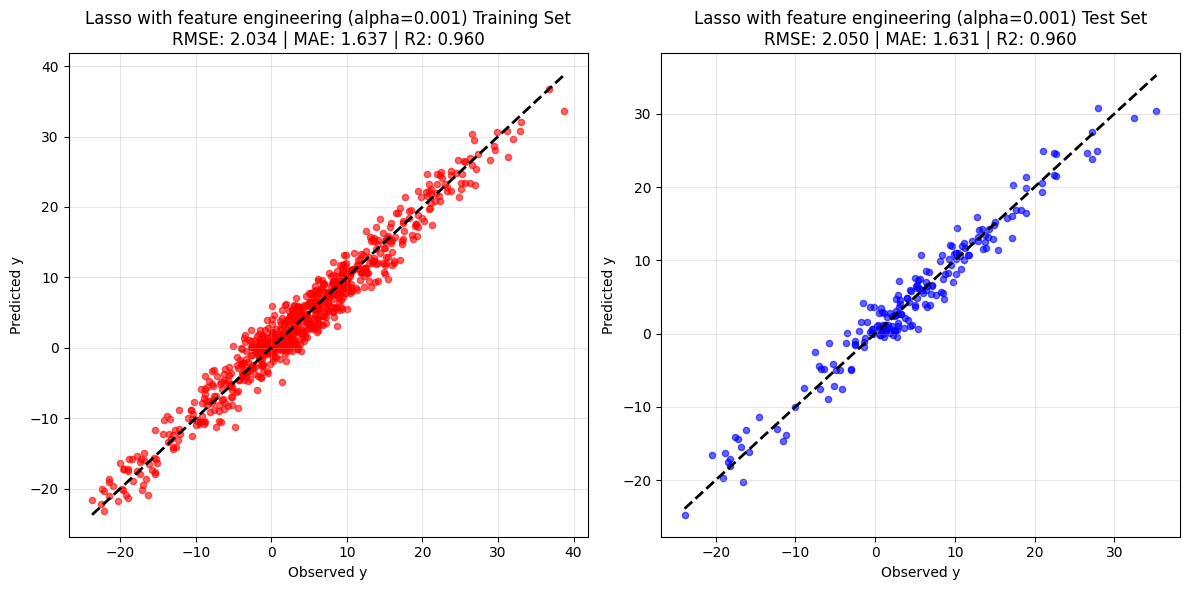

【特徴量の削減結果】
・元の特徴量の数 : 12 個
・係数が0になった特徴量の数 : 1 個
・予測に残った特徴量の数 : 11 個
       Feature  Coefficient
11    x4_cubed     0.917028
4   x1_squared     0.368901
3           x4    -0.007569
0           x1    -0.003016
2           x3     0.002877
9     x3_cubed    -0.002175
6   x2_squared    -0.002001
10  x4_squared     0.001941
5     x1_cubed    -0.001345
7     x2_cubed    -0.000640
8   x3_squared    -0.000626
1           x2     0.000000


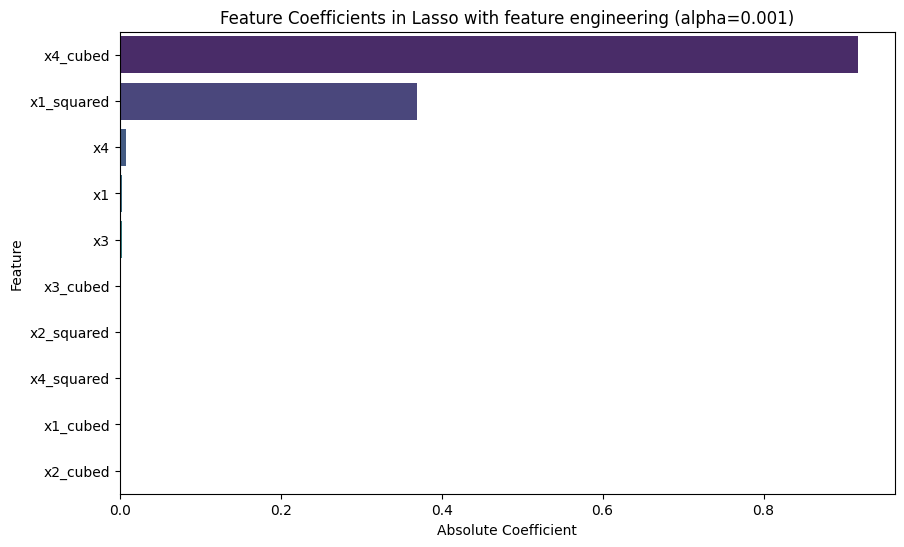

In [23]:
pred_plot(y_train, pred_y_train, y_test, pred_y_test, model_name) #* 評価指標の表示と予測値-実測値プロットの描画
feature_importance_lasso(model, auto_X_train, model_name) #* Lassoの係数と重要な特徴量を確認